<a href="https://colab.research.google.com/github/Suvathi88/projects/blob/main/MEDALLION_ARCHITECTURE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyspark opendatasets


In [3]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/rajneesh231/retail-insights-a-comprehensive-sales-dataset")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: suvathi21
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rajneesh231/retail-insights-a-comprehensive-sales-dataset


100%|██████████| 951k/951k [00:00<00:00, 284MB/s]

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Bronze Layer - Retail Sales") \
    .getOrCreate()


In [5]:
raw_path = "/content/retail-insights-a-comprehensive-sales-dataset"

import os
print(os.listdir(raw_path))


['data.csv', 'data.xlsx']


In [6]:
raw_df = spark.read.csv(
    "/content/retail-insights-a-comprehensive-sales-dataset/data.csv",
    header=True,
    inferSchema=True
)

raw_df.show(5)
raw_df.printSchema()

+-------------------+----------+--------------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+---------+
|           Order No|Order Date|       Customer Name|             Address|     City|State| Customer Type|Account Manager|Order Priority|        Product Name|Product Category|Product Container|  Ship Mode| Ship Date|Cost Price|Retail Price|Profit Margin|Order Quantity|Sub Total|Discount %|Discount $|Order Total|Shipping Cost|    Total|
+-------------------+----------+--------------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+

In [7]:
from pyspark.sql.functions import year, month, dayofmonth, current_timestamp, to_date
raw_df = raw_df.withColumn("sales_date", to_date("Order Date", "dd-MM-yyyy"))

bronze_df = raw_df.withColumn("ingestion_time", current_timestamp()) \
                  .withColumn("year", year("sales_date")) \
                  .withColumn("month", month("sales_date")) \
                  .withColumn("day", dayofmonth("sales_date"))

In [8]:
bronze_path = "/content/lakehouse/bronze/retail_sales"


In [9]:
bronze_df.write \
    .mode("append") \
    .partitionBy("year", "month", "day") \
    .parquet(bronze_path)


In [10]:
import os

for root, dirs, files in os.walk(bronze_path):
    level = root.replace(bronze_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


retail_sales/
    _SUCCESS
    ._SUCCESS.crc
    year=2017/
        month=2/
            day=7/
                part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet
                .part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet.crc
            day=1/
                part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet
                .part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet.crc
            day=3/
                part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet
                .part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet.crc
            day=5/
                part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet
                .part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet.crc
            day=4/
                part-00000-ca4850ef-8f21-407c-b3d4-8f74937e0d98.c000.snappy.parquet
                .part-00000-ca4850ef-8f21-407c-b3d4-

In [ ]:
bronze_read_df = spark.read.parquet(bronze_path)
bronze_read_df.show(5)


+-------------------+----------+---------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+--------------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+-------+----------+--------------------+----+-----+---+
|           Order No|Order Date|  Customer Name|             Address|     City|State| Customer Type|Account Manager|Order Priority|        Product Name|Product Category|Product Container|     Ship Mode| Ship Date|Cost Price|Retail Price|Profit Margin|Order Quantity|Sub Total|Discount %|Discount $|Order Total|Shipping Cost|  Total|sales_date|      ingestion_time|year|month|day|
+-------------------+----------+---------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+--------------+----------+----------+------------+---

INCREMENTAL STRATEGY

In [11]:
source_folder = "/content/incoming_sales_files"
os.makedirs(source_folder, exist_ok=True)


In [12]:
log_file = "/content/processed_files.txt"

# Create log file if not exists
if not os.path.exists(log_file):
    open(log_file, 'w').close()


In [13]:
import os

def get_new_files(source_folder, log_file):
    all_files = [f for f in os.listdir(source_folder) if f.endswith(".csv")]

    with open(log_file, 'r') as f:
        processed_files = f.read().splitlines()

    new_files = [f for f in all_files if f not in processed_files]
    return new_files


In [14]:
from pyspark.sql.functions import current_timestamp, year, month, dayofmonth

new_files = get_new_files(source_folder, log_file)

for file in new_files:
    print(f"Processing new file: {file}")

    file_path = os.path.join(source_folder, file)

    raw_df = spark.read.csv(file_path, header=True, inferSchema=True)

    bronze_df = raw_df.withColumn("ingestion_time", current_timestamp()) \
                      .withColumn("year", year("ingestion_time")) \
                      .withColumn("month", month("ingestion_time")) \
                      .withColumn("day", dayofmonth("ingestion_time"))

    bronze_df.write \
        .mode("append") \
        .partitionBy("year", "month", "day") \
        .parquet(bronze_path)

    # Mark file as processed
    with open(log_file, 'a') as log:
        log.write(file + "\n")


In [15]:
!pip install pyspark opendatasets


In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rajneesh231/retail-insights-a-comprehensive-sales-dataset")


Skipping, found downloaded files in "./retail-insights-a-comprehensive-sales-dataset" (use force=True to force download)


In [16]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Bronze Layer - Retail Sales") \
    .getOrCreate()


In [17]:
raw_path = "/content/retail-insights-a-comprehensive-sales-dataset/data.csv"

raw_df = spark.read.csv(raw_path, header=True, inferSchema=True)

raw_df.show(5)
raw_df.printSchema()


+-------------------+----------+--------------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+---------+
|           Order No|Order Date|       Customer Name|             Address|     City|State| Customer Type|Account Manager|Order Priority|        Product Name|Product Category|Product Container|  Ship Mode| Ship Date|Cost Price|Retail Price|Profit Margin|Order Quantity|Sub Total|Discount %|Discount $|Order Total|Shipping Cost|    Total|
+-------------------+----------+--------------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+

In [22]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum, round, col, regexp_replace

# Ensure Spark session is initialized
spark = SparkSession.builder.getOrCreate()

# Check if the silver table exists before proceeding
if spark.catalog.tableExists("silver_db.silver_retail_sales"):
    # Aggregate data for the Gold Layer
    # We remove '$' and ',' symbols before casting to double for calculation
    gold_df = spark.table("silver_db.silver_retail_sales") \
        .withColumn("total_numeric", regexp_replace(col("total"), "[$,]", "").cast("double")) \
        .withColumn("profit_numeric", regexp_replace(col("profit_margin"), "[$,]", "").cast("double")) \
        .groupBy("product_category", "year") \
        .agg(
            round(sum(col("total_numeric")), 2).alias("total_revenue"),
            round(sum(col("profit_numeric")), 2).alias("total_profit")
        ) \
        .orderBy("year", "total_revenue", ascending=False)

    gold_df.show()

    # Save to Gold Table
    spark.sql("CREATE DATABASE IF NOT EXISTS gold_db")
    gold_df.write \
        .mode("overwrite") \
        .format("parquet") \
        .saveAsTable("gold_db.product_sales_summary")
else:
    print("Error: 'silver_db.silver_retail_sales' not found. Please execute the Silver Layer cells first to create the table.")

Error: 'silver_db.silver_retail_sales' not found. Please execute the Silver Layer cells first to create the table.


In [ ]:
from pyspark.sql.functions import year, month, dayofmonth, current_timestamp, to_date

# Create the missing 'sales_date' column by converting the 'Order Date' string
bronze_df = raw_df.withColumn("sales_date", to_date("Order Date", "dd-MM-yyyy")) \
                  .withColumn("ingestion_time", current_timestamp()) \
                  .withColumn("year", year("sales_date")) \
                  .withColumn("month", month("sales_date")) \
                  .withColumn("day", dayofmonth("sales_date"))

In [ ]:
bronze_path = "/content/lakehouse/bronze/retail_sales"

bronze_df.write \
    .mode("overwrite") \
    .partitionBy("year", "month", "day") \
    .parquet(bronze_path)

In [ ]:
import os

for root, dirs, files in os.walk(bronze_path):
    level = root.replace(bronze_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


retail_sales/
    ._SUCCESS.crc
    _SUCCESS
    year=2016/
        month=5/
            day=20/
                part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet
                .part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet.crc
            day=21/
                part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet
                .part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet.crc
            day=8/
                part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet
                .part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet.crc
            day=2/
                part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet
                .part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet.crc
            day=22/
                part-00000-0b875f67-2724-4017-b4d5-e31d65ebb20b.c000.snappy.parquet
                .part-00000-0b875f67-2724-4017-b4

In [23]:
bronze_read_df = spark.read.parquet(bronze_path)
bronze_read_df.show(5)


+-------------------+----------+---------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+--------------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+-------+----------+--------------------+----+-----+---+
|           Order No|Order Date|  Customer Name|             Address|     City|State| Customer Type|Account Manager|Order Priority|        Product Name|Product Category|Product Container|     Ship Mode| Ship Date|Cost Price|Retail Price|Profit Margin|Order Quantity|Sub Total|Discount %|Discount $|Order Total|Shipping Cost|  Total|sales_date|      ingestion_time|year|month|day|
+-------------------+----------+---------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+--------------+----------+----------+------------+---

In [24]:
source_folder = "/content/incoming_sales_files"
os.makedirs(source_folder, exist_ok=True)


In [25]:
log_file = "/content/processed_files.txt"

if not os.path.exists(log_file):
    open(log_file, 'w').close()


In [26]:
def get_new_files(source_folder, log_file):
    all_files = [f for f in os.listdir(source_folder) if f.endswith(".csv")]

    with open(log_file, 'r') as f:
        processed_files = f.read().splitlines()

    return [f for f in all_files if f not in processed_files]


In [27]:
from pyspark.sql.functions import to_date, year, month, dayofmonth, current_timestamp
import os

new_files = get_new_files(source_folder, log_file)

for file in new_files:
    print(f"Processing new file: {file}")

    file_path = os.path.join(source_folder, file)
    raw_df = spark.read.csv(file_path, header=True, inferSchema=True)

    raw_df = raw_df.withColumn("sales_date", to_date("Date", "MM/dd/yyyy"))

    bronze_df = raw_df.withColumn("ingestion_time", current_timestamp()) \
                      .withColumn("year", year("sales_date")) \
                      .withColumn("month", month("sales_date")) \
                      .withColumn("day", dayofmonth("sales_date"))

    bronze_df.write \
        .mode("append") \
        .partitionBy("year", "month", "day") \
        .parquet(bronze_path)

    # Mark file as processed
    with open(log_file, 'a') as log:
        log.write(file + "\n")


In [28]:
bronze_read_df = spark.read.parquet(bronze_path)
bronze_read_df.filter("year = 2017 AND month = 1 AND day = 3").show()

+-------------------+----------+-------------+--------------------+------+-----+--------------+----------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+---------+----------+--------------------+----+-----+---+
|           Order No|Order Date|Customer Name|             Address|  City|State| Customer Type| Account Manager|Order Priority|        Product Name|Product Category|Product Container|  Ship Mode| Ship Date|Cost Price|Retail Price|Profit Margin|Order Quantity|Sub Total|Discount %|Discount $|Order Total|Shipping Cost|    Total|sales_date|      ingestion_time|year|month|day|
+-------------------+----------+-------------+--------------------+------+-----+--------------+----------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+------

SILVER LAYER


In [29]:
from pyspark.sql import SparkSession

# Initialize Spark Session if not already started
spark = SparkSession.builder \
    .appName("Silver Layer - Retail Sales") \
    .getOrCreate()

bronze_path = "/content/lakehouse/bronze/retail_sales"

# Read the bronze data
bronze_df = spark.read.parquet(bronze_path)
bronze_df.show(5)

+-------------------+----------+---------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+--------------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+-------+----------+--------------------+----+-----+---+
|           Order No|Order Date|  Customer Name|             Address|     City|State| Customer Type|Account Manager|Order Priority|        Product Name|Product Category|Product Container|     Ship Mode| Ship Date|Cost Price|Retail Price|Profit Margin|Order Quantity|Sub Total|Discount %|Discount $|Order Total|Shipping Cost|  Total|sales_date|      ingestion_time|year|month|day|
+-------------------+----------+---------------+--------------------+---------+-----+--------------+---------------+--------------+--------------------+----------------+-----------------+--------------+----------+----------+------------+---

In [30]:
from pyspark.sql.functions import col

# Make column names lowercase & remove spaces
for column in bronze_df.columns:
    bronze_df = bronze_df.withColumnRenamed(column, column.strip().lower().replace(" ", "_"))

silver_df = bronze_df.dropDuplicates()


In [31]:
from pyspark.sql.functions import to_date

silver_df = silver_df.withColumn("order_date", to_date(col("order_date"), "yyyy-MM-dd"))


In [32]:
spark.sql("CREATE DATABASE IF NOT EXISTS silver_db")
spark.sql("USE silver_db")


DataFrame[]

In [33]:
from pyspark.sql.functions import col

# Fix: Cast 'order_no' to string to avoid parsing conflicts and use the
# correctly formatted 'sales_date' for the 'order_date' column.
silver_df.withColumn("order_no", col("order_no").cast("string")) \
    .withColumn("order_date", col("sales_date")) \
    .write \
    .mode("overwrite") \
    .partitionBy("year", "month", "day") \
    .format("parquet") \
    .saveAsTable("silver_retail_sales")

In [34]:
spark.sql("SHOW TABLES").show()

spark.sql("SELECT * FROM silver_retail_sales LIMIT 5").show()


+---------+-------------------+-----------+
|namespace|          tableName|isTemporary|
+---------+-------------------+-----------+
|silver_db|silver_retail_sales|      false|
+---------+-------------------+-----------+

+-------------------+----------+----------------+--------------------+------+-----+-------------+------------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+---------+----------+--------------------+----+-----+---+
|           order_no|order_date|   customer_name|             address|  city|state|customer_type|   account_manager|order_priority|        product_name|product_category|product_container|  ship_mode| ship_date|cost_price|retail_price|profit_margin|order_quantity|sub_total|discount_%|discount_$|order_total|shipping_cost|    total|sales_date|      ingestion_time|year|month|day|
+-------------------+

In [35]:
spark.sql("""
SELECT * FROM silver_retail_sales
WHERE year = 2014 AND month = 1 AND day = 30
""").show()


+-------------------+----------+--------------+--------------------+------+-----+--------------+----------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+-------+----------+--------------------+----+-----+---+
|           order_no|order_date| customer_name|             address|  city|state| customer_type| account_manager|order_priority|        product_name|product_category|product_container|  ship_mode| ship_date|cost_price|retail_price|profit_margin|order_quantity|sub_total|discount_%|discount_$|order_total|shipping_cost|  total|sales_date|      ingestion_time|year|month|day|
+-------------------+----------+--------------+--------------------+------+-----+--------------+----------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+-------

In [36]:
from pyspark.sql.functions import col

new_bronze_df = spark.read.parquet(bronze_path)

# Apply same cleaning steps
for column in new_bronze_df.columns:
    new_bronze_df = new_bronze_df.withColumnRenamed(column, column.strip().lower().replace(" ", "_"))

new_silver_df = new_bronze_df.dropDuplicates()

# Fix: Ensure types and column mapping match the existing silver table
new_silver_df.withColumn("order_no", col("order_no").cast("string")) \
    .withColumn("order_date", col("sales_date")) \
    .write \
    .mode("append") \
    .partitionBy("year", "month", "day") \
    .format("parquet") \
    .saveAsTable("silver_db.silver_retail_sales")

In [37]:
spark.sql("SHOW TABLES IN silver_db").show()


+---------+-------------------+-----------+
|namespace|          tableName|isTemporary|
+---------+-------------------+-----------+
|silver_db|silver_retail_sales|      false|
+---------+-------------------+-----------+



In [38]:
spark.sql("DESCRIBE FORMATTED silver_db.silver_retail_sales").show(200, False)


+----------------------------+--------------------------------------------------------------+-------+
|col_name                    |data_type                                                     |comment|
+----------------------------+--------------------------------------------------------------+-------+
|order_no                    |string                                                        |NULL   |
|order_date                  |date                                                          |NULL   |
|customer_name               |string                                                        |NULL   |
|address                     |string                                                        |NULL   |
|city                        |string                                                        |NULL   |
|state                       |string                                                        |NULL   |
|customer_type               |string                                              

In [39]:
spark.sql("SELECT COUNT(*) FROM silver_db.silver_retail_sales").show()


+--------+
|count(1)|
+--------+
|   10000|
+--------+



In [40]:
spark.sql("SHOW PARTITIONS silver_retail_sales").show(truncate=False)


+-------------------------+
|partition                |
+-------------------------+
|year=2013/month=10/day=1 |
|year=2013/month=10/day=11|
|year=2013/month=10/day=13|
|year=2013/month=10/day=2 |
|year=2013/month=10/day=20|
|year=2013/month=10/day=21|
|year=2013/month=10/day=23|
|year=2013/month=10/day=24|
|year=2013/month=10/day=25|
|year=2013/month=10/day=26|
|year=2013/month=10/day=27|
|year=2013/month=10/day=28|
|year=2013/month=10/day=29|
|year=2013/month=10/day=3 |
|year=2013/month=10/day=4 |
|year=2013/month=10/day=5 |
|year=2013/month=10/day=6 |
|year=2013/month=10/day=9 |
|year=2013/month=11/day=1 |
|year=2013/month=11/day=15|
+-------------------------+
only showing top 20 rows


In [41]:
# Access records for a specific date, e.g., 2014-01-30
spark.sql("""
SELECT *
FROM silver_db.silver_retail_sales
WHERE year = 2014 AND month = 1 AND day = 30
""").show()


+-------------------+----------+--------------+--------------------+------+-----+--------------+----------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+-------+----------+--------------------+----+-----+---+
|           order_no|order_date| customer_name|             address|  city|state| customer_type| account_manager|order_priority|        product_name|product_category|product_container|  ship_mode| ship_date|cost_price|retail_price|profit_margin|order_quantity|sub_total|discount_%|discount_$|order_total|shipping_cost|  total|sales_date|      ingestion_time|year|month|day|
+-------------------+----------+--------------+--------------------+------+-----+--------------+----------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+-------

In [42]:
from pyspark.sql.functions import col, to_timestamp

bronze_path = "/content/lakehouse/bronze/retail_sales"
bronze_df = spark.read.parquet(bronze_path)

# Convert to proper timestamp if not already
bronze_df = bronze_df.withColumn(
    "sales_ts",
    to_timestamp(col("sales_date"))
)


In [43]:
watermark_path = "/content/lakehouse/watermark/silver_watermark.txt"

import os

if os.path.exists(watermark_path):
    with open(watermark_path, "r") as f:
        last_watermark = f.read().strip()
else:
    last_watermark = "1900-01-01 00:00:00"  # first run

print("Last Watermark:", last_watermark)


Last Watermark: 1900-01-01 00:00:00


In [44]:
incremental_df = bronze_df.filter(col("sales_ts") > last_watermark)

print("New Records Count:", incremental_df.count())


New Records Count: 5000


In [45]:
from pyspark.sql.functions import current_timestamp

# Standardize column names
for column in incremental_df.columns:
    incremental_df = incremental_df.withColumnRenamed(
        column, column.strip().lower().replace(" ", "_")
    )

silver_df = incremental_df.dropDuplicates()

silver_df = silver_df.withColumn("processed_time", current_timestamp())


In [46]:
from pyspark.sql.functions import col

# Get the list of columns from the existing table to ensure alignment
target_columns = spark.table("silver_db.silver_retail_sales").columns

# Align the DataFrame:
# 1. Cast order_no to string
# 2. Use the date-typed 'sales_date' for 'order_date'
# 3. Select only the columns present in the target table
final_silver_df = silver_df.withColumn("order_no", col("order_no").cast("string")) \
                           .withColumn("order_date", col("sales_date")) \
                           .select(*target_columns)

final_silver_df.write \
    .mode("append") \
    .format("parquet") \
    .partitionBy("year", "month", "day") \
    .saveAsTable("silver_db.silver_retail_sales")

In [47]:
from pyspark.sql.functions import max
import os

new_watermark = silver_df.select(max("sales_ts")).collect()[0][0]

if new_watermark:
    # Ensure the directory exists before writing the file
    os.makedirs(os.path.dirname(watermark_path), exist_ok=True)
    with open(watermark_path, "w") as f:
        f.write(str(new_watermark))

print("Updated Watermark:", new_watermark)

Updated Watermark: 2017-02-07 00:00:00


EXAMPLE


In [48]:
from pyspark.sql.functions import col, to_timestamp

bronze_path = "/content/lakehouse/bronze/retail_sales"
bronze_df = spark.read.parquet(bronze_path)

bronze_df = bronze_df.withColumn("sales_ts", to_timestamp(col("sales_date")))


In [49]:
watermark_path = "/content/lakehouse/watermark/silver_watermark.txt"
import os

if os.path.exists(watermark_path):
    last_watermark = spark.read.text(watermark_path).collect()[0][0]
else:
    last_watermark = "1900-01-01 00:00:00"  # first ever run


In [50]:
incremental_df = bronze_df.filter(col("sales_ts") > last_watermark)


In [51]:
from pyspark.sql.functions import current_timestamp

# Clean column names
for c in incremental_df.columns:
    incremental_df = incremental_df.withColumnRenamed(c, c.strip().lower().replace(" ", "_"))

silver_df = incremental_df.dropDuplicates()

silver_df = silver_df.withColumn("processed_time", current_timestamp())


In [52]:
if silver_df.count() > 0:
    silver_df.write \
        .mode("append") \
        .format("parquet") \
        .partitionBy("year", "month", "day") \
        .saveAsTable("silver_db.silver_retail_sales")

    print("New data appended to Silver layer")
else:
    print("No new data found — Silver layer unchanged")


No new data found — Silver layer unchanged


In [53]:
from pyspark.sql.functions import max

new_watermark = silver_df.select(max("sales_ts")).collect()[0][0]

if new_watermark:
    spark.createDataFrame([(str(new_watermark),)], ["watermark"]) \
         .write.mode("overwrite").text(watermark_path)

    print("Watermark updated to:", new_watermark)


In [54]:
from pyspark.sql.functions import max

# Fallback to 'ingestion_time' since 'processed_time' was not yet added to the table schema
try:
    # Find latest batch time
    latest_batch_time = spark.sql("""
    SELECT MAX(ingestion_time) FROM silver_db.silver_retail_sales
    """).collect()[0][0]

    print("Latest Batch Time (ingestion_time):", latest_batch_time)

    # Show only data loaded in last run
    if latest_batch_time:
        spark.sql(f"""
        SELECT *
        FROM silver_db.silver_retail_sales
        WHERE ingestion_time = TIMESTAMP('{latest_batch_time}')
        """).show(truncate=False)
    else:
        print("Table is empty.")
except Exception as e:
    print(f"Error: {e}")

Latest Batch Time (ingestion_time): 2026-02-03 05:43:02.933109
+-------------------+----------+--------------------+------------------------------------+---------+-----+--------------+------------------+--------------+-----------------------------------------------------------------------+----------------+-----------------+--------------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+---------+----------+--------------------------+----+-----+---+
|order_no           |order_date|customer_name       |address                             |city     |state|customer_type |account_manager   |order_priority|product_name                                                           |product_category|product_container|ship_mode     |ship_date |cost_price|retail_price|profit_margin|order_quantity|sub_total|discount_%|discount_$|order_total|shipping_cost|total    |sales_date|ingestion_time            |year|month|day|
+----------

GOLD LAYER


In [60]:
silver_df = spark.table("silver_db.silver_retail_sales")
silver_df.show(5)


+-------------------+----------+----------------+--------------------+------+-----+-------------+------------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+---------+----------+--------------------+----+-----+---+
|           order_no|order_date|   customer_name|             address|  city|state|customer_type|   account_manager|order_priority|        product_name|product_category|product_container|  ship_mode| ship_date|cost_price|retail_price|profit_margin|order_quantity|sub_total|discount_%|discount_$|order_total|shipping_cost|    total|sales_date|      ingestion_time|year|month|day|
+-------------------+----------+----------------+--------------------+------+-----+-------------+------------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+--------

In [62]:
from pyspark.sql.functions import sum, year, col, round, regexp_replace

# Fix: Use the correct column names 'total' and 'profit_margin' instead of 'sales' and 'profit'.
# Also, clean currency symbols ($ and ,) and cast to double before aggregating.
gold_sales_summary = silver_df \
    .withColumn("order_year", year(col("order_date"))) \
    .withColumn("total_numeric", regexp_replace(col("total"), "[$,]", "").cast("double")) \
    .withColumn("profit_numeric", regexp_replace(col("profit_margin"), "[$,]", "").cast("double")) \
    .groupBy("product_category", "order_year") \
    .agg(
        round(sum("total_numeric"), 2).alias("total_revenue"),
        round(sum("profit_numeric"), 2).alias("total_profit")
    ) \
    .orderBy("order_year", "total_revenue", ascending=False)

gold_sales_summary.show()

+----------------+----------+-------------+------------+
|product_category|order_year|total_revenue|total_profit|
+----------------+----------+-------------+------------+
| Office Supplies|      2017|    195475.53|     5171.28|
|      Technology|      2017|      32746.5|      804.54|
|       Furniture|      2017|      1495.62|       62.97|
| Office Supplies|      2016|   2120901.51|    54687.48|
|      Technology|      2016|    520398.42|    16741.62|
|       Furniture|      2016|     59215.17|     1253.91|
| Office Supplies|      2015|   2436198.63|    50078.82|
|      Technology|      2015|    505314.51|    11387.49|
|       Furniture|      2015|     44247.09|      794.25|
| Office Supplies|      2014|   2302291.71|    49829.01|
|      Technology|      2014|    607639.98|     12148.5|
|       Furniture|      2014|     68065.23|     1984.71|
| Office Supplies|      2013|    1727489.7|    49878.42|
|      Technology|      2013|    465390.27|    12773.85|
|       Furniture|      2013|  

In [64]:
from pyspark.sql.functions import sum, round, col, regexp_replace

# Fix: Use correct column names 'total' and 'profit_margin' instead of 'sales' and 'profit'.
# Also clean the currency formatting ($ and ,) and cast to double for aggregation.
gold_customer_summary = silver_df \
    .withColumn("total_numeric", regexp_replace(col("total"), "[$,]", "").cast("double")) \
    .withColumn("profit_numeric", regexp_replace(col("profit_margin"), "[$,]", "").cast("double")) \
    .groupBy("customer_type") \
    .agg(
        round(sum("total_numeric"), 2).alias("total_sales"),
        round(sum("profit_numeric"), 2).alias("total_profit")
    )

gold_customer_summary.show()

+--------------+-----------+------------+
| customer_type|total_sales|total_profit|
+--------------+-----------+------------+
|      Consumer| 2025694.95|    45804.75|
|   Home Office| 2554865.88|    64066.98|
|     Corporate| 4121389.32|    103624.5|
|Small Business| 2492659.05|    56444.67|
+--------------+-----------+------------+



In [67]:
from pyspark.sql.functions import month, year, sum, round, col, regexp_replace

# Fix: Use the correct column name 'total' and clean currency formatting before aggregating.
gold_monthly_trend = silver_df \
    .withColumn("order_year", year("order_date")) \
    .withColumn("order_month", month("order_date")) \
    .withColumn("total_numeric", regexp_replace(col("total"), "[$,]", "").cast("double")) \
    .groupBy("order_year", "order_month") \
    .agg(round(sum("total_numeric"), 2).alias("monthly_sales")) \
    .orderBy("order_year", "order_month")

gold_monthly_trend.show()

+----------+-----------+-------------+
|order_year|order_month|monthly_sales|
+----------+-----------+-------------+
|      2013|          2|     95623.11|
|      2013|          3|    104859.51|
|      2013|          4|     46406.34|
|      2013|          5|    326136.33|
|      2013|          6|    326543.67|
|      2013|          7|    363399.87|
|      2013|          8|     263761.8|
|      2013|          9|    170529.42|
|      2013|         10|    249209.25|
|      2013|         11|     86043.21|
|      2013|         12|    268106.79|
|      2014|          1|    258742.74|
|      2014|          2|     509629.5|
|      2014|          3|     98961.93|
|      2014|          4|    150186.12|
|      2014|          5|    353474.82|
|      2014|          6|    142963.32|
|      2014|          7|     92797.35|
|      2014|          8|     66800.82|
|      2014|          9|    209001.21|
+----------+-----------+-------------+
only showing top 20 rows


In [69]:
import os

# Define the dimension path
dim_path = "/content/lakehouse/dimensions/customers"

# Check if the path exists; if not, create it from the silver table
if not os.path.exists(dim_path):
    print("Dimension path not found. Creating customer dimension from Silver Layer...")

    # Extract customer attributes from the silver table
    silver_df = spark.table("silver_db.silver_retail_sales")
    customer_dim_df = silver_df.select(
        "customer_name", "address", "city", "state", "customer_type"
    ).dropDuplicates()

    # Save to the target path in Parquet format
    customer_dim_df.write.mode("overwrite").parquet(dim_path)
    print(f"Customer dimension saved to {dim_path}")

# Now read the dimension table
customer_dim = spark.read.parquet(dim_path)
customer_dim.show(5)

Dimension path not found. Creating customer dimension from Silver Layer...
Customer dimension saved to /content/lakehouse/dimensions/customers
+--------------------+--------------------+---------+-----+--------------+
|       customer_name|             address|     city|state| customer_type|
+--------------------+--------------------+---------+-----+--------------+
|         Cyra Reiten|Westfield 1 Ander...|   Sydney|  NSW|     Corporate|
|         Rick Wilson|438 Victoria Aven...|   Sydney|  NSW|      Consumer|
|Christopher Martinez|188 Pitt Street,S...|   Sydney|  NSW|Small Business|
|Christopher Martinez|273 George Street...|   Sydney|  NSW|Small Business|
|        Allen Armold|224A Gertrude St,...|Melbourne|  VIC|Small Business|
+--------------------+--------------------+---------+-----+--------------+
only showing top 5 rows


In [71]:
# Fix: Join on 'customer_name' since 'customer_id' is not present in the schema.
gold_enriched = silver_df.join(
    customer_dim,
    on="customer_name",
    how="left"
)

gold_enriched.show()

+----------------+-------------------+----------+--------------------+------+-----+-------------+------------------+--------------+--------------------+----------------+-----------------+-----------+----------+----------+------------+-------------+--------------+---------+----------+----------+-----------+-------------+-------+----------+--------------------+----+-----+---+--------------------+------+-----+--------------+
|   customer_name|           order_no|order_date|             address|  city|state|customer_type|   account_manager|order_priority|        product_name|product_category|product_container|  ship_mode| ship_date|cost_price|retail_price|profit_margin|order_quantity|sub_total|discount_%|discount_$|order_total|shipping_cost|  total|sales_date|      ingestion_time|year|month|day|             address|  city|state| customer_type|
+----------------+-------------------+----------+--------------------+------+-----+-------------+------------------+--------------+-----------------

In [72]:
spark.sql("CREATE DATABASE IF NOT EXISTS gold_db")

gold_sales_summary.write \
    .mode("overwrite") \
    .format("parquet") \
    .saveAsTable("gold_db.sales_summary_by_category")

gold_customer_summary.write \
    .mode("overwrite") \
    .format("parquet") \
    .saveAsTable("gold_db.sales_by_customer_type")

gold_monthly_trend.write \
    .mode("overwrite") \
    .format("parquet") \
    .saveAsTable("gold_db.monthly_sales_trend")


In [73]:
spark.sql("SHOW TABLES IN gold_db").show()


+---------+--------------------+-----------+
|namespace|           tableName|isTemporary|
+---------+--------------------+-----------+
|  gold_db| monthly_sales_trend|      false|
|  gold_db|sales_by_customer...|      false|
|  gold_db|sales_summary_by_...|      false|
+---------+--------------------+-----------+



In [74]:
spark.sql("""
SELECT *
FROM gold_db.sales_summary_by_category
ORDER BY order_year DESC, total_revenue DESC
""").show()


+----------------+----------+-------------+------------+
|product_category|order_year|total_revenue|total_profit|
+----------------+----------+-------------+------------+
| Office Supplies|      2017|    195475.53|     5171.28|
|      Technology|      2017|      32746.5|      804.54|
|       Furniture|      2017|      1495.62|       62.97|
| Office Supplies|      2016|   2120901.51|    54687.48|
|      Technology|      2016|    520398.42|    16741.62|
|       Furniture|      2016|     59215.17|     1253.91|
| Office Supplies|      2015|   2436198.63|    50078.82|
|      Technology|      2015|    505314.51|    11387.49|
|       Furniture|      2015|     44247.09|      794.25|
| Office Supplies|      2014|   2302291.71|    49829.01|
|      Technology|      2014|    607639.98|     12148.5|
|       Furniture|      2014|     68065.23|     1984.71|
| Office Supplies|      2013|    1727489.7|    49878.42|
|      Technology|      2013|    465390.27|    12773.85|
|       Furniture|      2013|  

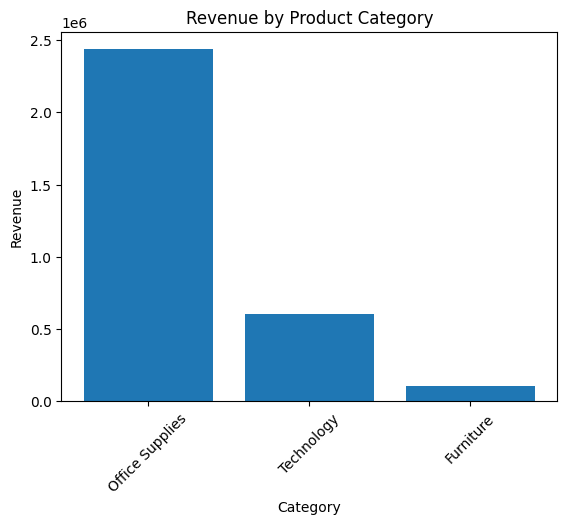

In [75]:
import matplotlib.pyplot as plt

df = spark.table("gold_db.sales_summary_by_category").toPandas()

plt.figure()
plt.bar(df["product_category"], df["total_revenue"])
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


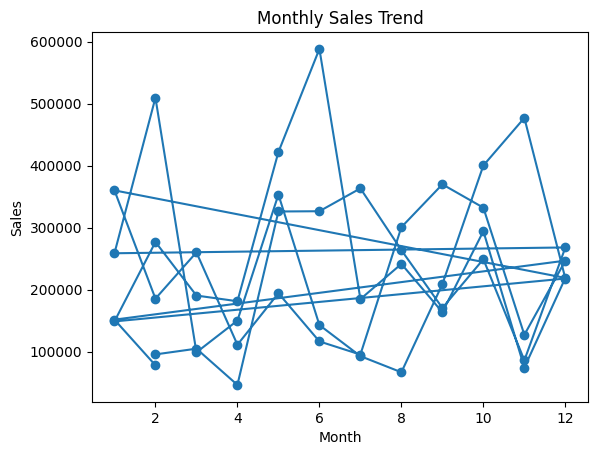

In [76]:
df3 = spark.table("gold_db.monthly_sales_trend").toPandas()
df3 = df3.sort_values(["order_year","order_month"])

plt.figure()
plt.plot(df3["order_month"], df3["monthly_sales"], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()
